In [1]:
!pip install onnx
!pip install onnxscript
!pip install onnx2torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 5.9 MB/s eta 0:00:00


In [2]:
import os
import requests

from scipy.io import loadmat

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np

import matplotlib.pyplot as plt

from onnx2torch import convert
from onnx2torch.utils.common import OperationConverterResult, onnx_mapping_from_node
from onnx2torch.node_converters.registry import add_converter

import copy


In [28]:
def compute_l1_norm(model):
  l1 = 0
  for name, param in model.named_parameters():
    # Check if the parameter name contains 'weight' and does NOT contain 'bias'
    # The 'weight' check is often redundant if you skip 'bias', but good practice.
    # The key is to check for 'bias' in the name and skip it.
    if 'bias' not in name:
      l1 += torch.sum(torch.abs(param))

  return l1

# Download Test Data and Models

In [3]:
def download_file(repo_path, local_folder):
  if not os.path.exists(local_folder):
    os.makedirs(local_folder)

  filename = os.path.basename(repo_path)
  local_path = os.path.join(local_folder, filename)

  print(f"Downloading {filename} ...")
  response = requests.get(repo_path)
  if response.status_code == 200:
    with open(local_path, 'wb') as f:
      f.write(response.content)
    print(f"Downloaded {filename} to {local_path}")
  else:
    print(f"Failed to download {filename}. Status code: {response.status_code}")

In [4]:
base_url = "https://raw.githubusercontent.com/loonwerks/vnncomp2022/main/"

files_to_download = [
    ("data/test_data_w20.mat", "data"),
    ("data/test_data_w40.mat", "data"),
    ("data/if_then_properties_5levels.mat", "data"),
    ("onnx/NN_rul_full_window_20.onnx", "onnx"),
    ("onnx/NN_rul_full_window_40.onnx", "onnx"),
    ("onnx/NN_rul_small_window_20.onnx", "onnx")
]

for repo_path, local_folder in files_to_download:
  download_file(base_url + repo_path, local_folder)

Downloaded test_data_w20.mat to data/test_data_w20.mat
Downloaded test_data_w40.mat to data/test_data_w40.mat
Downloaded if_then_properties_5levels.mat to data/if_then_properties_5levels.mat
Downloaded NN_rul_full_window_20.onnx to onnx/NN_rul_full_window_20.onnx
Downloaded NN_rul_full_window_40.onnx to onnx/NN_rul_full_window_40.onnx
Downloaded NN_rul_small_window_20.onnx to onnx/NN_rul_small_window_20.onnx


# First Look at Test Data

In [5]:
test_data_w20 = loadmat("data/test_data_w20.mat")
test_data_w40 = loadmat("data/test_data_w40.mat")

print(test_data_w20.keys())
print(test_data_w40.keys())

dict_keys(['__header__', '__version__', '__globals__', 'sequences'])
dict_keys(['__header__', '__version__', '__globals__', 'sequences'])


The networks are trained on windows of $20$ and $40$ timesteps.

In each time step, the readings of $20$ sensor values are captured.

In [6]:
print(test_data_w20['sequences'][0][0][0].shape)
print(test_data_w20['sequences'][0][0][1].shape)

(20, 20)
(1, 1)


In [7]:
print(test_data_w40['sequences'][0][0][0].shape)
print(test_data_w40['sequences'][0][0][1].shape)

(40, 20)
(1, 1)


In [8]:
test_data_w20['sequences'][0].shape

(5000,)

In [9]:
X20_test = np.array([s[0] for s in test_data_w20['sequences'][0]])
y20_test = np.array([s[1][0][0] for s in test_data_w20['sequences'][0]])

X40_test = np.array([s[0] for s in test_data_w40['sequences'][0]])
y40_test = np.array([s[1][0][0] for s in test_data_w40['sequences'][0]])

In [10]:
X40_test.shape

(2500, 40, 20)

In [11]:
class RULDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.float32).view(-1, 1)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, idx):
    return self.features[idx], self.labels[idx]

The different samples are just snapshots of the same time series shifted by one unit of time.

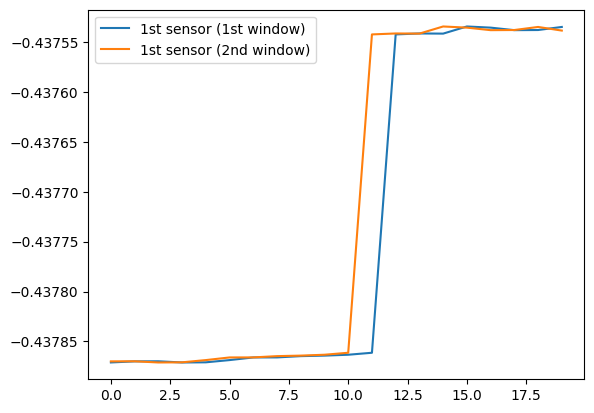

In [12]:
plt.plot(X20_test[0,:,0], label="1st sensor (1st window)")
plt.plot(X20_test[1,:,0], label="1st sensor (2nd window)")
plt.legend()
plt.show()

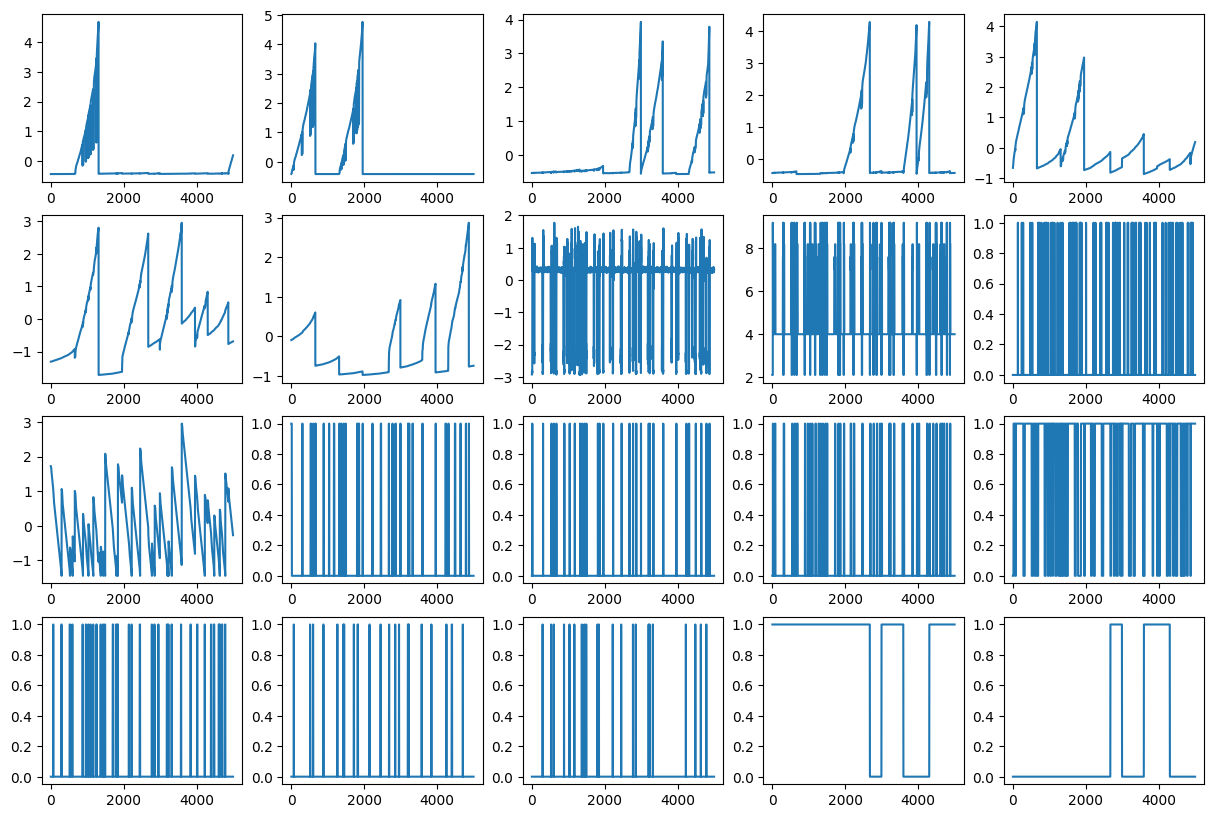

In [13]:
fig, ax = plt.subplots(4, 5, figsize=(15, 10))
ax = ax.flatten()

for i in range(20):
  ax[i].plot(X20_test[:,0,i])

plt.show()

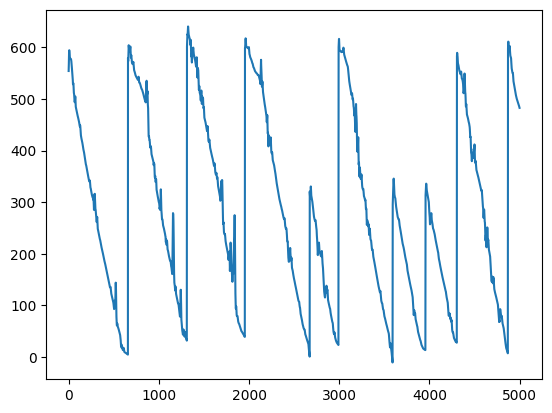

In [14]:
plt.plot(y20_test)

## Bounds for each Dimension

In [61]:
min_vals = X20_test.min(0).min(0)
max_vals = X20_test.max(0).max(0)

print(min_vals)
print(max_vals)

[-0.43787118 -0.4170134  -0.56220525 -0.47313478 -0.87071895 -1.71500653
 -0.97503717 -2.93923836  2.1         0.         -1.44232638  0.
  0.          0.          0.          0.          0.          0.
  0.          0.        ]
[5.12792935 5.65973052 5.13137438 5.48585691 4.33442824 3.24138691
 3.06227229 1.77278949 9.2        1.         2.95009876 1.
 1.         1.         1.         1.         1.         1.
 1.         1.        ]


## Export Test Data to CSV

In [64]:
np.savetxt("data/X20_test.csv", X20_test.reshape(5000, -1), delimiter=",")
np.savetxt("data/y20_test.csv", y20_test, delimiter=",")

# First Look at the Models

Since `onnx2torch` doesn't support these layers (at least not in the specified version) out of the box, we have to add them ourselves.

In [15]:
@add_converter(operation_type="Dropout", version=7)
def _(node, graph):
  return OperationConverterResult(
      torch_module=nn.Identity(),
      onnx_mapping=onnx_mapping_from_node(node=node)
  )

@add_converter(operation_type="Flatten", version=1)
def _(node, graph):
  axis = node.attributes.get('axis', 1)
  return OperationConverterResult(
      torch_module=nn.Flatten(start_dim=axis),
      onnx_mapping=onnx_mapping_from_node(node=node)
  )

In [16]:
onnx_path = "onnx/NN_rul_small_window_20.onnx"
model = convert(onnx_path)

onnx_path = "onnx/NN_rul_full_window_20.onnx"
model_full = convert(onnx_path)

In [17]:
X20_test_tensor = torch.tensor(X20_test, dtype=torch.float32)
# add 1 as channel dimension, otherwise the 5000 is used as channel dim
X20_test_tensor = X20_test_tensor.unsqueeze(1)
y20_hat = model(X20_test_tensor).detach().numpy().reshape(-1)
y20_hat_full = model_full(X20_test_tensor).detach().numpy().reshape(-1)

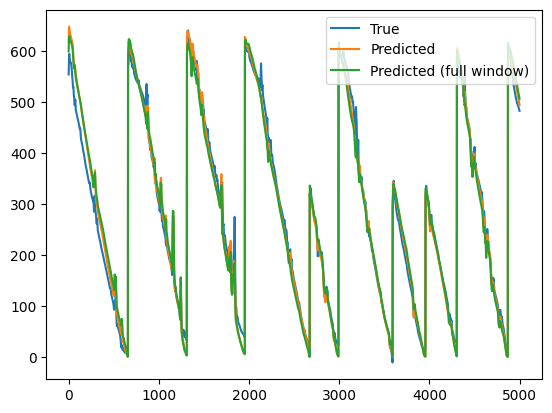

In [18]:
plt.plot(y20_test, label="True")
plt.plot(y20_hat, label="Predicted")
plt.plot(y20_hat_full, label="Predicted (full window)")
plt.legend()
plt.show()

# Swap ReLU for GeLU

In [19]:
def replace_relu_gelu(model_input):
  # work on a copy of the input model to avoid overwrite
  model = copy.deepcopy(model_input)

  for name, module in model.named_children():
    if isinstance(module, nn.ReLU):
      setattr(model, name, nn.GELU())

    if len(list(module.children())) > 0:
      replace_relu_gelu(module)

  return model

In [20]:
model_gelu = replace_relu_gelu(model)
model_full_gelu = replace_relu_gelu(model_full)

In [21]:
y20_hat_gelu = model_gelu(X20_test_tensor).detach().numpy().reshape(-1)
y20_hat_full_gelu = model_full_gelu(X20_test_tensor).detach().numpy().reshape(-1)

Even without any retraining, the GeLU models are not *that* much worse than the original ReLU networks.

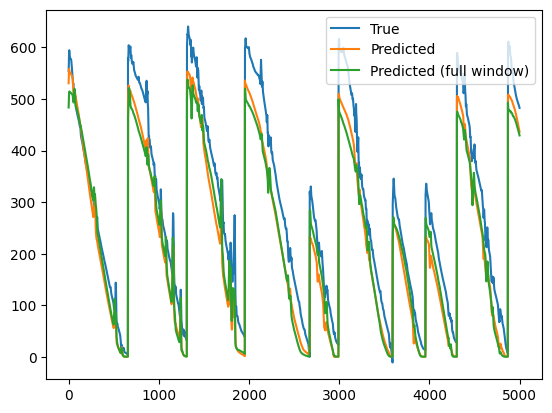

In [22]:
plt.plot(y20_test, label="True")
plt.plot(y20_hat_gelu, label="Predicted")
plt.plot(y20_hat_full_gelu, label="Predicted (full window)")
plt.legend()
plt.show()

In [23]:
print(nn.MSELoss()(torch.tensor(y20_hat_full), torch.tensor(y20_test)))
print(nn.MSELoss()(torch.tensor(y20_hat_full_gelu), torch.tensor(y20_test)))

tensor(673.5620)
tensor(4323.4556)


# Retraining with Random Inputs

In [30]:
def retrain(student, teacher, X_test, y_test, rand_mode='normal', batch_dim=32,
            eval_freq=10, lr=1e-4, l1_weight=0., epochs=100):
  student.train()
  teacher.eval()

  input_shape = (batch_dim,) + X_test.shape[1:]
  min_vals = X_test.min(dim=0)[0].min(dim=1)[0]
  max_vals = X_test.max(dim=0)[0].max(dim=1)[0]

  data_mean = X_test.mean(dim=0)
  data_std  = X_test.std(dim=0)

  optimizer = torch.optim.Adam(student.parameters(), lr=lr)
  loss_fn = nn.MSELoss()

  train_losses = []
  test_losses  = []
  for epoch in range(epochs):
    student.train()

    if rand_mode == 'minmax':
      X_rand = torch.rand(input_shape) * (max_vals - min_vals) + min_vals
    elif rand_mode == 'normal':
      X_rand = (torch.randn(input_shape) * data_std) + data_mean

    optimizer.zero_grad()

    with torch.no_grad():
      y_teacher = teacher(X_rand)

    y_student = student(X_rand)
    loss = loss_fn(y_student, y_teacher)

    if l1_weight > 0:
      l1_loss = compute_l1_norm(student)
      loss += l1_weight * l1_loss

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    if (epoch+1) % eval_freq == 0:
      # evaluation
      student.eval()
      y_test_hat = student(X_test).reshape(-1)
      test_loss = loss_fn(y_test_hat, y_test)

      print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item()} - Test Loss: {test_loss.item()}")

      if l1_weight > 0:
        print(f"L1 Norm: {l1_loss.item()}")

      test_losses.append(test_loss.item())

  return train_losses, test_losses

## Small Model

We really need to use mean and standard deviation to sample the random data - for min-max scaling there is no progress (i.e. training loss is zero and no gradient updates, likely because everything is so much out of distribution...).

In [43]:
batch_dim = 128
epochs = 2500
X_test = X20_test_tensor
y_test = torch.tensor(y20_test, dtype=torch.float32)

train_losses, test_losses = retrain(model_gelu, model, X_test, y_test, epochs=epochs, batch_dim=batch_dim)

Epoch 10/2500 - Loss: 104.42247009277344 - Test Loss: 2766.073974609375
Epoch 20/2500 - Loss: 74.12931823730469 - Test Loss: 3014.4794921875
Epoch 30/2500 - Loss: 67.0957260131836 - Test Loss: 3125.43603515625
Epoch 40/2500 - Loss: 56.71512985229492 - Test Loss: 2981.674072265625
Epoch 50/2500 - Loss: 39.234344482421875 - Test Loss: 3026.112060546875
Epoch 60/2500 - Loss: 51.52308654785156 - Test Loss: 2968.789306640625
Epoch 70/2500 - Loss: 51.89390182495117 - Test Loss: 2897.852294921875
Epoch 80/2500 - Loss: 42.400177001953125 - Test Loss: 2907.896728515625
Epoch 90/2500 - Loss: 47.52654266357422 - Test Loss: 2801.16748046875
Epoch 100/2500 - Loss: 42.75590515136719 - Test Loss: 2731.563232421875
Epoch 110/2500 - Loss: 50.83287048339844 - Test Loss: 2651.287109375
Epoch 120/2500 - Loss: 39.16461944580078 - Test Loss: 2560.981201171875
Epoch 130/2500 - Loss: 45.6383056640625 - Test Loss: 2539.05712890625
Epoch 140/2500 - Loss: 34.34074401855469 - Test Loss: 2400.9951171875
Epoch 150/

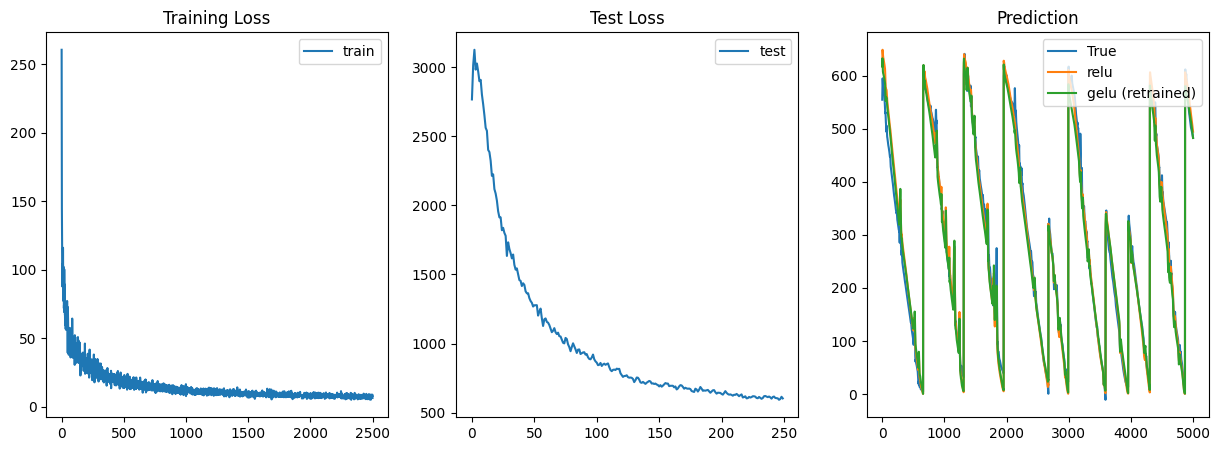

In [44]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(train_losses, label="train")
ax[0].set_title('Training Loss')
ax[0].legend()

ax[1].plot(test_losses, label="test")
ax[1].set_title('Test Loss')
ax[1].legend()

y20_hat_gelu = model_gelu(X20_test_tensor).detach().numpy().reshape(-1)
ax[2].plot(y20_test, label="True")
ax[2].plot(y20_hat, label="relu")
ax[2].plot(y20_hat_gelu, label="gelu (retrained)")
ax[2].set_title("Prediction")
ax[2].legend()

plt.show()

In [135]:
dummy_input = torch.randn(1, 20, 20)
filename = "onnx/NN_rul_small_window_20_gelu.onnx"
torch.onnx.export(model_gelu, dummy_input, filename, export_params=True, do_constant_folding=True, input_names=['input'], output_names=['output'],
                  opset_version=20, external_data=False)

W0417 11:55:39.642000 8456 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0417 11:55:39.644000 8456 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0417 11:55:39.646000 8456 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0417 11:55:39.648000 8456 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,20,20]>
            ),
            outputs=(
                %"output"<FLOAT,[1,1]>
            ),
            initializers=(
                %"conv_1.weight"<FLOAT,[5,1,5,1]>{TorchTensor(...)},
                %"conv_1.bias"<FLOAT,[5]>{TorchTensor<FLOAT,[5]>(Parameter containing: tensor([0.2818, 0.2364, 0.1280, 0.2403, 0.1660], requires_grad=True), name='conv_1.bias')},
                %"conv_2.weight"<FLOAT,[10,5,5,1]>{TorchTensor(...)},
                %"conv_2.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([ 0.1178,  0.1947,  0.0916,  0.1347, -0.0014,  0.1677, -0.0137,  0.1605, 0.0392,  0.2070], requires_grad=True), name=

## Large Model

In [25]:
batch_dim = 128
epochs = 25000
X_test = X20_test_tensor
y_test = torch.tensor(y20_test, dtype=torch.float32)

train_losses, test_losses = retrain(model_full_gelu, model_full, X_test, y_test, epochs=epochs, batch_dim=batch_dim)

Epoch 10/25000 - Loss: 546.0814819335938 - Test Loss: 6996.79541015625
Epoch 20/25000 - Loss: 253.1874542236328 - Test Loss: 9168.841796875
Epoch 30/25000 - Loss: 280.6158752441406 - Test Loss: 9690.0419921875
Epoch 40/25000 - Loss: 231.49270629882812 - Test Loss: 9048.0927734375
Epoch 50/25000 - Loss: 254.82937622070312 - Test Loss: 8501.54296875
Epoch 60/25000 - Loss: 208.74099731445312 - Test Loss: 8460.994140625
Epoch 70/25000 - Loss: 205.90518188476562 - Test Loss: 8669.099609375
Epoch 80/25000 - Loss: 164.3059844970703 - Test Loss: 8771.6376953125
Epoch 90/25000 - Loss: 180.8719482421875 - Test Loss: 8569.568359375
Epoch 100/25000 - Loss: 110.22116088867188 - Test Loss: 8445.2451171875
Epoch 110/25000 - Loss: 180.88088989257812 - Test Loss: 8559.2607421875
Epoch 120/25000 - Loss: 129.2971954345703 - Test Loss: 8655.41796875
Epoch 130/25000 - Loss: 125.11356353759766 - Test Loss: 8475.19921875
Epoch 140/25000 - Loss: 122.8348388671875 - Test Loss: 8417.716796875
Epoch 150/25000 - 

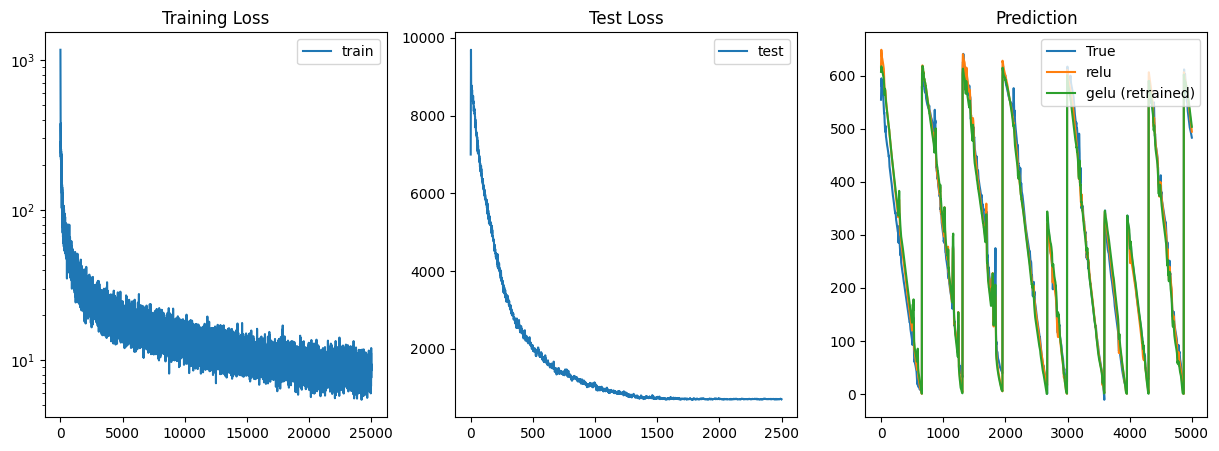

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(train_losses, label="train")
ax[0].set_yscale('log')
ax[0].set_title('Training Loss')
ax[0].legend()

ax[1].plot(test_losses, label="test")
ax[1].set_title('Test Loss')
ax[1].legend()

y20_hat_gelu = model_full_gelu(X20_test_tensor).detach().numpy().reshape(-1)
ax[2].plot(y20_test, label="True")
ax[2].plot(y20_hat, label="relu")
ax[2].plot(y20_hat_gelu, label="gelu (retrained)")
ax[2].set_title("Prediction")
ax[2].legend()

plt.show()

In [26]:
dummy_input = torch.randn(1, 20, 20)
filename = "onnx/NN_rul_window_20_gelu.onnx"
torch.onnx.export(model_full_gelu, dummy_input, filename, export_params=True, do_constant_folding=True, input_names=['input'], output_names=['output'],
                  opset_version=20, external_data=False)

W0417 16:21:20.336000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0417 16:21:20.337000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0417 16:21:20.340000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0417 16:21:20.342000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,20,20]>
            ),
            outputs=(
                %"output"<FLOAT,[1,1]>
            ),
            initializers=(
                %"conv_1.weight"<FLOAT,[10,1,5,1]>{TorchTensor(...)},
                %"conv_1.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([-0.0075,  0.1274,  0.0280, -0.1043,  0.1575, -0.0023,  0.1915,  0.1891, -0.2541,  0.0266], requires_grad=True), name='conv_1.bias')},
                %"conv_2.weight"<FLOAT,[20,10,5,1]>{TorchTensor(...)},
                %"conv_2.bias"<FLOAT,[20]>{TorchTensor(...)},
                %"conv_3.weight"<FLOAT,[10,20,5,1]>{TorchTensor(...)},
                %"conv_3

# Add L1 Penalty

## Small Model

### 2e-5

In [45]:
l1_weight = 2e-5
batch_dim = 128
epochs = 5000
X_test = X20_test_tensor
y_test = torch.tensor(y20_test, dtype=torch.float32)

model_gelu_2e5 = copy.deepcopy(model_gelu)

train_losses, test_losses = retrain(model_gelu_2e5, model, X_test, y_test, epochs=epochs, batch_dim=batch_dim, l1_weight=l1_weight)

Epoch 10/5000 - Loss: 7.805741786956787 - Test Loss: 614.8651123046875
L1 Norm: 3276.439208984375
Epoch 20/5000 - Loss: 6.293582439422607 - Test Loss: 609.5217895507812
L1 Norm: 3264.576416015625
Epoch 30/5000 - Loss: 9.850786209106445 - Test Loss: 606.3950805664062
L1 Norm: 3252.514404296875
Epoch 40/5000 - Loss: 6.76424503326416 - Test Loss: 602.623779296875
L1 Norm: 3240.904052734375
Epoch 50/5000 - Loss: 5.594584941864014 - Test Loss: 593.886962890625
L1 Norm: 3229.745361328125
Epoch 60/5000 - Loss: 5.697925567626953 - Test Loss: 595.1753540039062
L1 Norm: 3218.807373046875
Epoch 70/5000 - Loss: 9.237618446350098 - Test Loss: 607.007080078125
L1 Norm: 3208.372314453125
Epoch 80/5000 - Loss: 7.009430885314941 - Test Loss: 602.3524780273438
L1 Norm: 3198.263916015625
Epoch 90/5000 - Loss: 8.244054794311523 - Test Loss: 598.5966796875
L1 Norm: 3187.880615234375
Epoch 100/5000 - Loss: 7.770662784576416 - Test Loss: 599.9365234375
L1 Norm: 3178.527099609375
Epoch 110/5000 - Loss: 6.9975

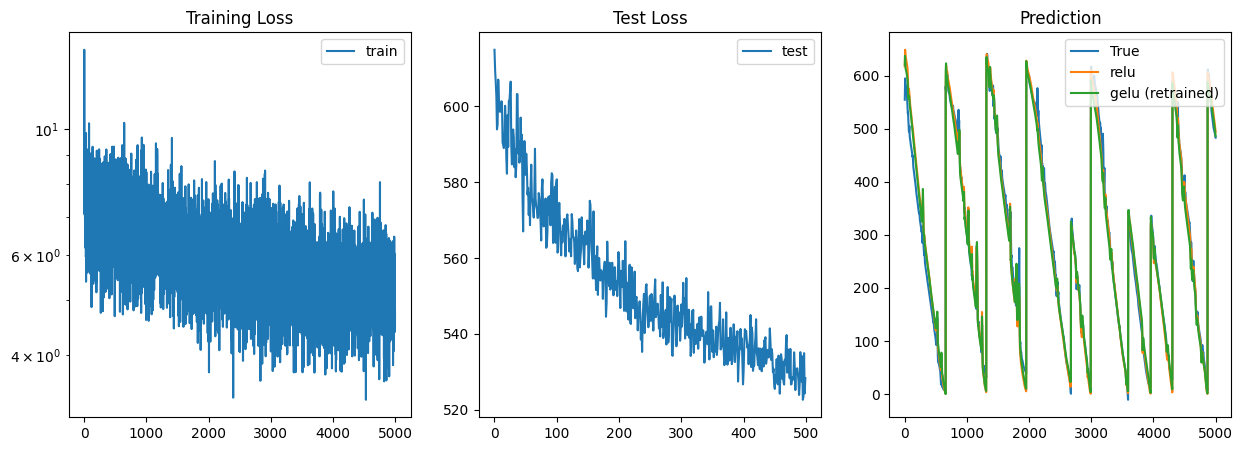

In [46]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(train_losses, label="train")
ax[0].set_yscale('log')
ax[0].set_title('Training Loss')
ax[0].legend()

ax[1].plot(test_losses, label="test")
ax[1].set_title('Test Loss')
ax[1].legend()

y20_hat_gelu = model_gelu_2e5(X20_test_tensor).detach().numpy().reshape(-1)
ax[2].plot(y20_test, label="True")
ax[2].plot(y20_hat, label="relu")
ax[2].plot(y20_hat_gelu, label="gelu (retrained)")
ax[2].set_title("Prediction")
ax[2].legend()

plt.show()

In [47]:
dummy_input = torch.randn(1, 20, 20)
filename = "onnx/NN_rul_small_window_20_gelu_2e-5l1.onnx"
torch.onnx.export(model_gelu_2e5, dummy_input, filename, export_params=True, do_constant_folding=True, input_names=['input'], output_names=['output'],
                  opset_version=20, external_data=False)

W0417 17:17:20.853000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0417 17:17:20.855000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0417 17:17:20.857000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0417 17:17:20.858000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,20,20]>
            ),
            outputs=(
                %"output"<FLOAT,[1,1]>
            ),
            initializers=(
                %"conv_1.weight"<FLOAT,[5,1,5,1]>{TorchTensor(...)},
                %"conv_1.bias"<FLOAT,[5]>{TorchTensor<FLOAT,[5]>(Parameter containing: tensor([0.3069, 0.2721, 0.1330, 0.2779, 0.1859], requires_grad=True), name='conv_1.bias')},
                %"conv_2.weight"<FLOAT,[10,5,5,1]>{TorchTensor(...)},
                %"conv_2.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([ 0.1194,  0.2038,  0.0935,  0.1386, -0.0052,  0.1807, -0.0162,  0.1651, 0.0415,  0.2263], requires_grad=True), nam

### 1e-3

In [48]:
l1_weight = 1e-3
batch_dim = 128
epochs = 5000
X_test = X20_test_tensor
y_test = torch.tensor(y20_test, dtype=torch.float32)

model_gelu_1e3 = copy.deepcopy(model_gelu)

train_losses, test_losses = retrain(model_gelu_1e3, model, X_test, y_test, epochs=epochs, batch_dim=batch_dim, l1_weight=l1_weight)

Epoch 10/5000 - Loss: 10.629984855651855 - Test Loss: 611.0640258789062
L1 Norm: 3275.13037109375
Epoch 20/5000 - Loss: 11.46091079711914 - Test Loss: 604.5789794921875
L1 Norm: 3261.298828125
Epoch 30/5000 - Loss: 11.667932510375977 - Test Loss: 610.765625
L1 Norm: 3247.169677734375
Epoch 40/5000 - Loss: 10.827022552490234 - Test Loss: 611.5505981445312
L1 Norm: 3234.079345703125
Epoch 50/5000 - Loss: 11.540164947509766 - Test Loss: 595.9187622070312
L1 Norm: 3221.2900390625
Epoch 60/5000 - Loss: 10.11867618560791 - Test Loss: 599.7013549804688
L1 Norm: 3208.371826171875
Epoch 70/5000 - Loss: 10.583226203918457 - Test Loss: 597.027099609375
L1 Norm: 3195.427001953125
Epoch 80/5000 - Loss: 11.1206636428833 - Test Loss: 593.785400390625
L1 Norm: 3183.416015625
Epoch 90/5000 - Loss: 9.463372230529785 - Test Loss: 602.2534790039062
L1 Norm: 3170.747314453125
Epoch 100/5000 - Loss: 8.85757827758789 - Test Loss: 602.10498046875
L1 Norm: 3158.679443359375
Epoch 110/5000 - Loss: 11.4331169128

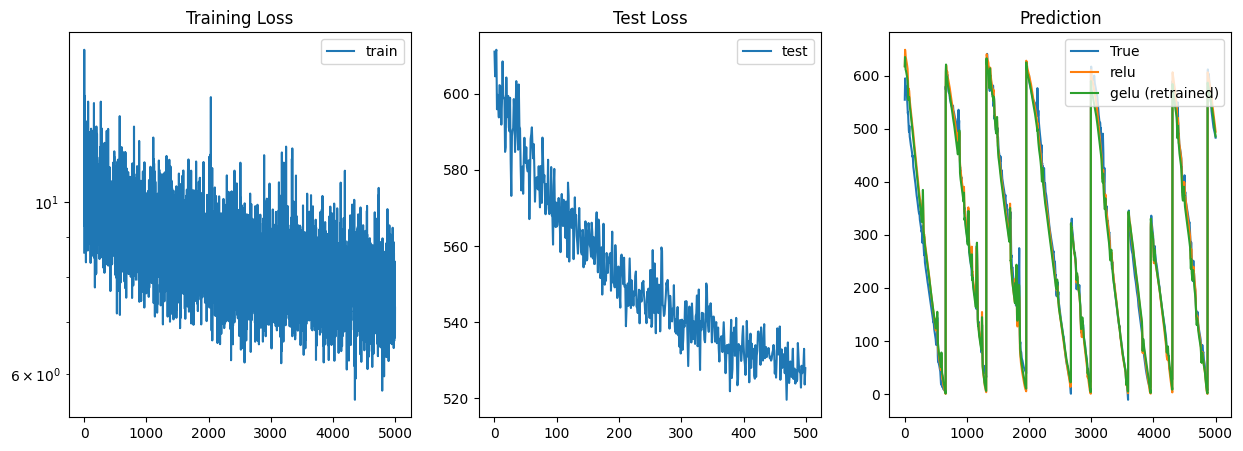

In [49]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(train_losses, label="train")
ax[0].set_yscale('log')
ax[0].set_title('Training Loss')
ax[0].legend()

ax[1].plot(test_losses, label="test")
ax[1].set_title('Test Loss')
ax[1].legend()

y20_hat_gelu = model_gelu_1e3(X20_test_tensor).detach().numpy().reshape(-1)
ax[2].plot(y20_test, label="True")
ax[2].plot(y20_hat, label="relu")
ax[2].plot(y20_hat_gelu, label="gelu (retrained)")
ax[2].set_title("Prediction")
ax[2].legend()

plt.show()

In [50]:
dummy_input = torch.randn(1, 20, 20)
filename = "onnx/NN_rul_small_window_20_gelu_1e-3l1.onnx"
torch.onnx.export(model_gelu_1e3, dummy_input, filename, export_params=True, do_constant_folding=True, input_names=['input'], output_names=['output'],
                  opset_version=20, external_data=False)

W0417 17:21:55.963000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0417 17:21:55.965000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0417 17:21:55.967000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0417 17:21:55.969000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,20,20]>
            ),
            outputs=(
                %"output"<FLOAT,[1,1]>
            ),
            initializers=(
                %"conv_1.weight"<FLOAT,[5,1,5,1]>{TorchTensor(...)},
                %"conv_1.bias"<FLOAT,[5]>{TorchTensor<FLOAT,[5]>(Parameter containing: tensor([0.3063, 0.2716, 0.1341, 0.2767, 0.1876], requires_grad=True), name='conv_1.bias')},
                %"conv_2.weight"<FLOAT,[10,5,5,1]>{TorchTensor(...)},
                %"conv_2.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([ 0.1202,  0.2033,  0.0943,  0.1394, -0.0053,  0.1806, -0.0171,  0.1648, 0.0433,  0.2268], requires_grad=True), nam

## Large Model

### 2e-5

In [32]:
l1_weight = 2e-5
batch_dim = 128
epochs = 5000
X_test = X20_test_tensor
y_test = torch.tensor(y20_test, dtype=torch.float32)

model_full_gelu_2e5 = copy.deepcopy(model_full_gelu)

train_losses, test_losses = retrain(model_full_gelu_2e5, model_full, X_test, y_test, epochs=epochs, batch_dim=batch_dim, l1_weight=l1_weight)

Epoch 10/5000 - Loss: 9.016307830810547 - Test Loss: 707.8541259765625
L1 Norm: 3767.72509765625
Epoch 20/5000 - Loss: 9.965909004211426 - Test Loss: 705.790771484375
L1 Norm: 3747.72021484375
Epoch 30/5000 - Loss: 8.18494987487793 - Test Loss: 707.6376342773438
L1 Norm: 3727.617431640625
Epoch 40/5000 - Loss: 7.079385280609131 - Test Loss: 712.85205078125
L1 Norm: 3708.5146484375
Epoch 50/5000 - Loss: 9.567543983459473 - Test Loss: 715.2310180664062
L1 Norm: 3689.461669921875
Epoch 60/5000 - Loss: 8.122942924499512 - Test Loss: 718.7869873046875
L1 Norm: 3671.068359375
Epoch 70/5000 - Loss: 8.185224533081055 - Test Loss: 727.0083618164062
L1 Norm: 3652.8076171875
Epoch 80/5000 - Loss: 9.757821083068848 - Test Loss: 724.889404296875
L1 Norm: 3634.9736328125
Epoch 90/5000 - Loss: 7.314574718475342 - Test Loss: 711.9389038085938
L1 Norm: 3617.063232421875
Epoch 100/5000 - Loss: 7.3859944343566895 - Test Loss: 705.7246704101562
L1 Norm: 3599.726318359375
Epoch 110/5000 - Loss: 6.438165664

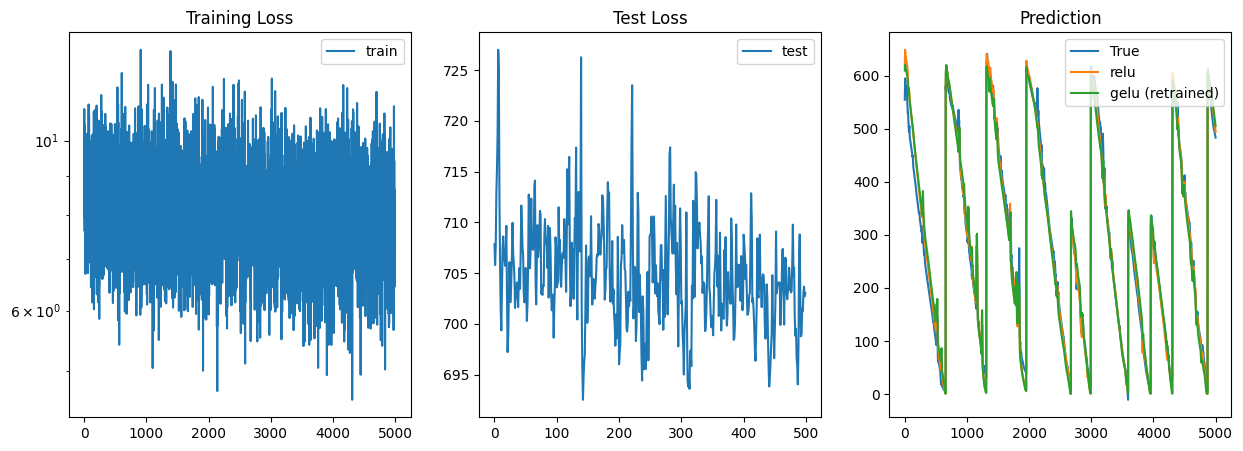

In [33]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(train_losses, label="train")
ax[0].set_yscale('log')
ax[0].set_title('Training Loss')
ax[0].legend()

ax[1].plot(test_losses, label="test")
ax[1].set_title('Test Loss')
ax[1].legend()

y20_hat_gelu = model_full_gelu_2e5(X20_test_tensor).detach().numpy().reshape(-1)
ax[2].plot(y20_test, label="True")
ax[2].plot(y20_hat, label="relu")
ax[2].plot(y20_hat_gelu, label="gelu (retrained)")
ax[2].set_title("Prediction")
ax[2].legend()

plt.show()

In [34]:
dummy_input = torch.randn(1, 20, 20)
filename = "onnx/NN_rul_window_20_gelu_2e-5l1.onnx"
torch.onnx.export(model_full_gelu_2e5, dummy_input, filename, export_params=True, do_constant_folding=True, input_names=['input'], output_names=['output'],
                  opset_version=20, external_data=False)

W0417 16:40:24.189000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0417 16:40:24.193000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0417 16:40:24.200000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0417 16:40:24.204000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,20,20]>
            ),
            outputs=(
                %"output"<FLOAT,[1,1]>
            ),
            initializers=(
                %"conv_1.weight"<FLOAT,[10,1,5,1]>{TorchTensor(...)},
                %"conv_1.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([-0.0090,  0.1254,  0.0227, -0.1033,  0.1569, -0.0037,  0.1921,  0.1893, -0.2542,  0.0262], requires_grad=True), name='conv_1.bias')},
                %"conv_2.weight"<FLOAT,[20,10,5,1]>{TorchTensor(...)},
                %"conv_2.bias"<FLOAT,[20]>{TorchTensor(...)},
                %"conv_3.weight"<FLOAT,[10,20,5,1]>{TorchTensor(...)},
                %"conv_3

### 1e-4

In [35]:
l1_weight = 1e-4
batch_dim = 128
epochs = 5000
X_test = X20_test_tensor
y_test = torch.tensor(y20_test, dtype=torch.float32)

model_full_gelu_1e4 = copy.deepcopy(model_full_gelu_2e5)

train_losses, test_losses = retrain(model_full_gelu_1e4, model_full, X_test, y_test, epochs=epochs, batch_dim=batch_dim, l1_weight=l1_weight)

Epoch 10/5000 - Loss: 8.961408615112305 - Test Loss: 699.6535034179688
L1 Norm: 2946.853759765625
Epoch 20/5000 - Loss: 9.45531177520752 - Test Loss: 701.7357788085938
L1 Norm: 2946.349609375
Epoch 30/5000 - Loss: 8.446529388427734 - Test Loss: 703.9688720703125
L1 Norm: 2945.913818359375
Epoch 40/5000 - Loss: 9.408742904663086 - Test Loss: 702.4421997070312
L1 Norm: 2945.31884765625
Epoch 50/5000 - Loss: 8.65230655670166 - Test Loss: 701.6937866210938
L1 Norm: 2944.97412109375
Epoch 60/5000 - Loss: 7.735826015472412 - Test Loss: 702.8319091796875
L1 Norm: 2944.796875
Epoch 70/5000 - Loss: 8.93656063079834 - Test Loss: 699.9052734375
L1 Norm: 2944.379150390625
Epoch 80/5000 - Loss: 10.096921920776367 - Test Loss: 699.2454833984375
L1 Norm: 2944.28369140625
Epoch 90/5000 - Loss: 9.37745189666748 - Test Loss: 697.2832641601562
L1 Norm: 2943.923828125
Epoch 100/5000 - Loss: 6.290651798248291 - Test Loss: 698.72021484375
L1 Norm: 2943.853271484375
Epoch 110/5000 - Loss: 8.591214179992676 -

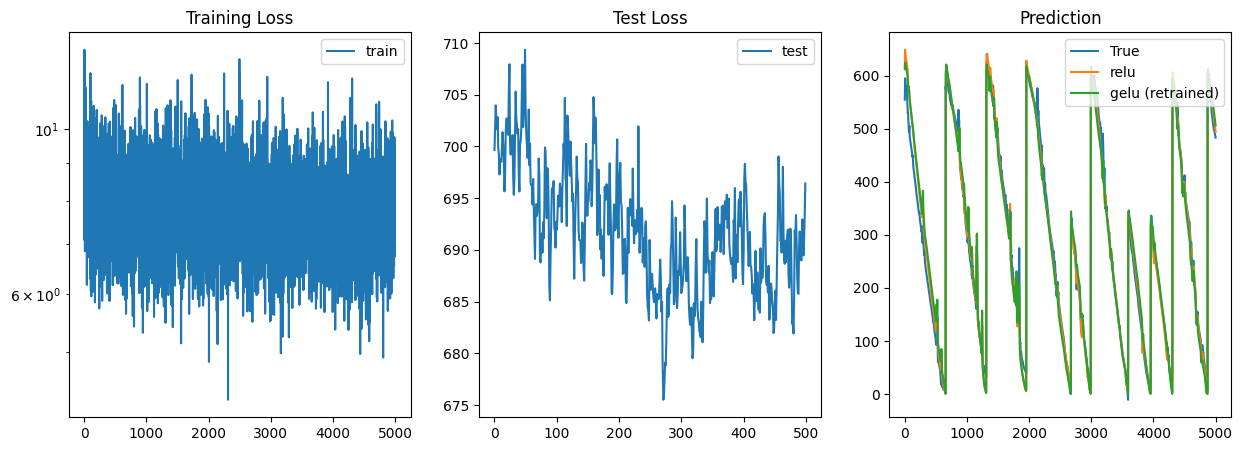

In [36]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(train_losses, label="train")
ax[0].set_yscale('log')
ax[0].set_title('Training Loss')
ax[0].legend()

ax[1].plot(test_losses, label="test")
ax[1].set_title('Test Loss')
ax[1].legend()

y20_hat_gelu = model_full_gelu_1e4(X20_test_tensor).detach().numpy().reshape(-1)
ax[2].plot(y20_test, label="True")
ax[2].plot(y20_hat, label="relu")
ax[2].plot(y20_hat_gelu, label="gelu (retrained)")
ax[2].set_title("Prediction")
ax[2].legend()

plt.show()

In [37]:
dummy_input = torch.randn(1, 20, 20)
filename = "onnx/NN_rul_window_20_gelu_1e-4l1.onnx"
torch.onnx.export(model_full_gelu_1e4, dummy_input, filename, export_params=True, do_constant_folding=True, input_names=['input'], output_names=['output'],
                  opset_version=20, external_data=False)

W0417 16:49:24.524000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0417 16:49:24.525000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0417 16:49:24.528000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0417 16:49:24.529000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,20,20]>
            ),
            outputs=(
                %"output"<FLOAT,[1,1]>
            ),
            initializers=(
                %"conv_1.weight"<FLOAT,[10,1,5,1]>{TorchTensor(...)},
                %"conv_1.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([-0.0099,  0.1238,  0.0180, -0.1026,  0.1562, -0.0049,  0.1928,  0.1896, -0.2543,  0.0259], requires_grad=True), name='conv_1.bias')},
                %"conv_2.weight"<FLOAT,[20,10,5,1]>{TorchTensor(...)},
                %"conv_2.bias"<FLOAT,[20]>{TorchTensor(...)},
                %"conv_3.weight"<FLOAT,[10,20,5,1]>{TorchTensor(...)},
                %"conv_3

### 1e-3

In [39]:
l1_weight = 1e-3
batch_dim = 128
epochs = 5000
X_test = X20_test_tensor
y_test = torch.tensor(y20_test, dtype=torch.float32)

model_full_gelu_1e3 = copy.deepcopy(model_full_gelu_1e4)

train_losses, test_losses = retrain(model_full_gelu_1e3, model_full, X_test, y_test, epochs=epochs, batch_dim=batch_dim, l1_weight=l1_weight)

Epoch 10/5000 - Loss: 9.915595054626465 - Test Loss: 688.736572265625
L1 Norm: 2901.4892578125
Epoch 20/5000 - Loss: 9.528444290161133 - Test Loss: 685.3382568359375
L1 Norm: 2900.426513671875
Epoch 30/5000 - Loss: 9.795943260192871 - Test Loss: 687.2171630859375
L1 Norm: 2899.44677734375
Epoch 40/5000 - Loss: 10.457365036010742 - Test Loss: 690.94091796875
L1 Norm: 2898.82568359375
Epoch 50/5000 - Loss: 11.339346885681152 - Test Loss: 689.135009765625
L1 Norm: 2898.11962890625
Epoch 60/5000 - Loss: 9.658653259277344 - Test Loss: 688.385498046875
L1 Norm: 2897.45947265625
Epoch 70/5000 - Loss: 9.868590354919434 - Test Loss: 687.2479858398438
L1 Norm: 2896.830322265625
Epoch 80/5000 - Loss: 8.82581901550293 - Test Loss: 687.4842529296875
L1 Norm: 2896.21923828125
Epoch 90/5000 - Loss: 9.344131469726562 - Test Loss: 689.9606323242188
L1 Norm: 2895.661865234375
Epoch 100/5000 - Loss: 8.091423034667969 - Test Loss: 688.3563232421875
L1 Norm: 2895.099609375
Epoch 110/5000 - Loss: 10.1934509

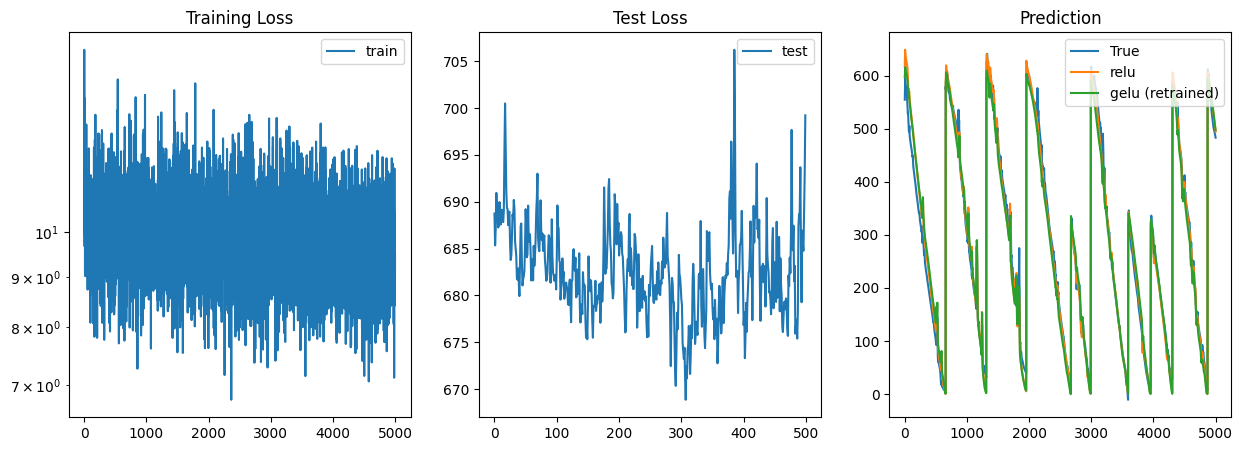

In [40]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(train_losses, label="train")
ax[0].set_yscale('log')
ax[0].set_title('Training Loss')
ax[0].legend()

ax[1].plot(test_losses, label="test")
ax[1].set_title('Test Loss')
ax[1].legend()

y20_hat_gelu = model_full_gelu_1e3(X20_test_tensor).detach().numpy().reshape(-1)
ax[2].plot(y20_test, label="True")
ax[2].plot(y20_hat, label="relu")
ax[2].plot(y20_hat_gelu, label="gelu (retrained)")
ax[2].set_title("Prediction")
ax[2].legend()

plt.show()

In [41]:
dummy_input = torch.randn(1, 20, 20)
filename = "onnx/NN_rul_window_20_gelu_1e-3l1.onnx"
torch.onnx.export(model_full_gelu_1e3, dummy_input, filename, export_params=True, do_constant_folding=True, input_names=['input'], output_names=['output'],
                  opset_version=20, external_data=False)

W0417 17:00:39.428000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0417 17:00:39.441000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0417 17:00:39.443000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0417 17:00:39.452000 3713 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,20,20]>
            ),
            outputs=(
                %"output"<FLOAT,[1,1]>
            ),
            initializers=(
                %"conv_1.weight"<FLOAT,[10,1,5,1]>{TorchTensor(...)},
                %"conv_1.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([-0.0110,  0.1227,  0.0142, -0.1023,  0.1545, -0.0054,  0.1908,  0.1896, -0.2553,  0.0262], requires_grad=True), name='conv_1.bias')},
                %"conv_2.weight"<FLOAT,[20,10,5,1]>{TorchTensor(...)},
                %"conv_2.bias"<FLOAT,[20]>{TorchTensor(...)},
                %"conv_3.weight"<FLOAT,[10,20,5,1]>{TorchTensor(...)},
                %"conv_3